# Progetto ML Adavanced

## Librerie e pacchetti

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Caricamento dati e prime analisi

In [5]:
# Caricamento del dataset
diabetes = load_diabetes()

# Creazione del DataFrame 
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Prime righe
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [6]:
df['target'] = diabetes.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Nel dataset "Diabetes" di scikit-learn, la variabile target è una misura quantitativa della progressione della malattia.

Si tratta di un punteggio numerico (che va da 25 a 346) che rappresenta lo stato di salute del paziente rispetto al diabete. Più alto è il numero, più la malattia è progredita (peggiorata) nel periodo di osservazione.

Target: 25 a 346. Se il target è basso, tipo 50, la malattia è progredita poco. Se il target è più vicino a 300 c'è stata una progressione significativa nel corso dell'anno.

La variabile Target è stata registrata dai medici durante lo studio originale.

Scikit-learn fornisce dati già stati scalati e centrati (hanno media 0 e la somma dei quadrati di ogni colonna è 1).

In [8]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.

Nel dataset sono presenti 442 righe, nessun valore nullo. Titti i campi sono numerici, perfetto per l'analisi.

### Heatmap
Viene creata una heatmap per visualizzare le correlazioni tra le variabili.

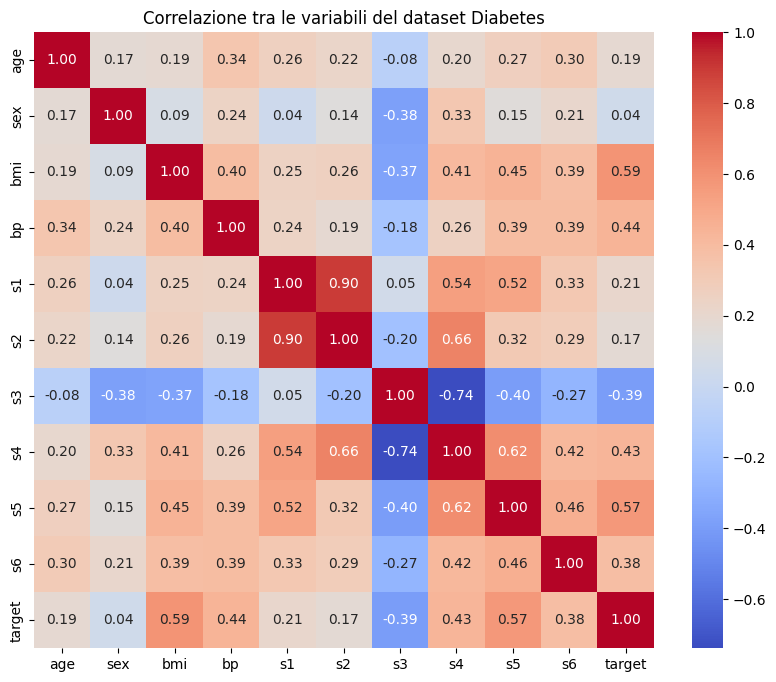

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlazione tra le variabili del dataset Diabetes")
plt.show()

Per prima cosa si osserva la riga/colonna target, per vedere quali variabili sono maggiormente correlate con la progressione della malattia. A prima vista non sembrano correlazioni molto forti, ma nella ricerca medica anche correlazioni moderate (tra 0.3 e 0.5) sono considerate segnali molto importanti. Sono 3 le variabili che si distinguono maggiormente:

- BMI (Indice di Massa Corporea) $\approx 0.59$. È la variabile con la correlazione più alta. Non sorprende che il sovrappeso sia uno dei predittori più forti per l'aggravamento del diabete di tipo 2.
-  s5 (logaritmo dei trigliceridi nel siero) $\approx 0.57$. Questa variabile è quasi importante quanto il BMI. I trigliceridi sono grassi nel sangue; un valore alto indica spesso una difficoltà del corpo a gestire l'insulina. Il fatto che sia così alta suggerisce che i dati biochimici sono fondamentali quanto quelli fisici.
-  bp (Pressione Sanguigna Media) $\approx 0.44$. È sotto lo 0.5, ma in un sistema complesso come il corpo umano, una correlazione di 0.44 non è trascurabile. Indica che chi ha la pressione più alta tende a avere una progressione della malattia più rapida.

### Grafici di dispersione
Per visualizzare meglio la relazione tra queste 3 variabili e la progressione della malattia vengono creati tre grafici di dispersione.

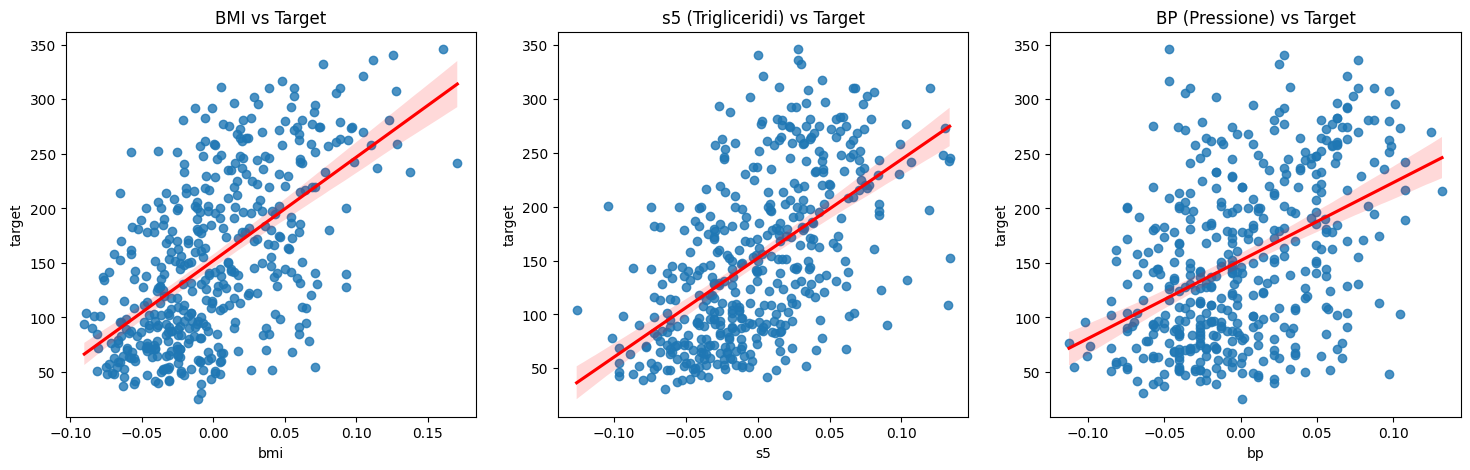

In [14]:
# Selezione solo top 3 e target per un confronto rapido
top_features = df[['bmi', 's5', 'bp', 'target']]

# Grafici di regressione per le top 3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(data=df, x='bmi', y='target', ax=axes[0], line_kws={'color':'red'})
axes[0].set_title('BMI vs Target')

sns.regplot(data=df, x='s5', y='target', ax=axes[1], line_kws={'color':'red'})
axes[1].set_title('s5 (Trigliceridi) vs Target')

sns.regplot(data=df, x='bp', y='target', ax=axes[2], line_kws={'color':'red'})
axes[2].set_title('BP (Pressione) vs Target')

plt.show()

Si nota subito che i punti del plot a destra, quello con il bp, sono più dispersi. Questo non stupisce data la correlazione più bassa, 0.44. La tendenza però è decisa, abbastanza pendente. Negli altri due grafici invece i punti sono più raccolti, e le rette più pendenti.


## Scelta del modello

In questa fase, si definisce una strategia di confronto tra diversi algoritmi di regressione per identificare quello più adatto a predire la progressione del diabete. Viene utilizzata una Pipeline per garantire la corretta standardizzazione dei dati e il GridSearchCV per ottimizzare gli iperparametri di ciascun modello, assicurando una valutazione robusta tramite Cross-Validation.

In [18]:
# Divisione dei dati: 80% per l'addestramento e 20% per il test finale
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset di addestramento: {X_train.shape[0]} pazienti")
print(f"Dataset di test: {X_test.shape[0]} pazienti")

Dataset di addestramento: 353 pazienti
Dataset di test: 89 pazienti


La sezione di codice seguente svolge tre funzioni fondamentali per garantire l'affidabilità dei risultati:

- **Standardizzazione Integrata** (Pipeline). In questo caso i dati sono già standardizzati, però si è scelto di inserire comunque uno scaler (StandardScaler) per rendere la pipeline riutilizzabile anche su dati grezzi. In generale è importante per garantire che variabili con scale diverse (es. Età vs Colesterolo) abbiano lo stesso "peso" iniziale, evitando distorsioni nel calcolo dei coefficienti.
  
- **Ricerca degli Iperparametri** (Grid Search):Il codice non testa solo il modello, ma cerca la sua configurazione migliore. Ad esempio, per il Lasso prova diversi valori di $\alpha$ per trovare quello che massimizza la capacità predittiva senza cadere nell'overfitting.
  
- **Validazione Incrociata** (5-Fold Cross-Validation): l'algoritmo divide i dati di addestramento in 5 parti, addestrando il modello su 4 e testandolo sulla quinta, a rotazione.Vantaggio: Il punteggio $R^2$ finale è la media di questi 5 test. Questo assicura prestazioni stabili e non dovute a un colpo di fortuna nella divisione dei dati.

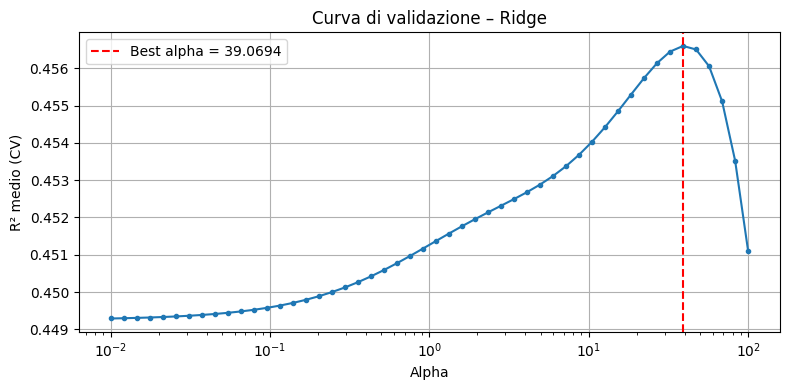

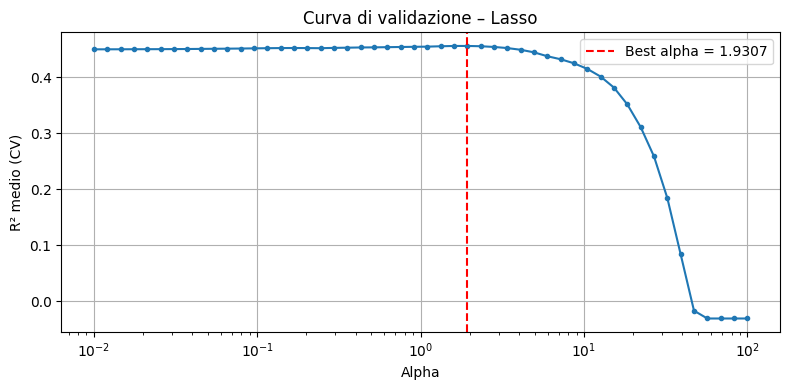

,Modello,Miglior R2 (CV),Miglior Parametro
0,Ridge,0.4566,{'model__alpha': 39.06939937054613}
1,Lasso,0.4555,{'model__alpha': 1.9306977288832496}
2,Random Forest,0.4070,"{'model__max_depth': 5, 'model__n_estimators': 200}"


In [20]:
# 1. Definizione dei modelli e delle griglie di parametri
alphas = np.logspace(-2, 2, 50)  # 50 valori da 0.01 a 100, scala log

models_to_test = [
    {
        'name': 'Ridge',
        'model': Ridge(),
        'params': {'model__alpha': alphas}
    },
    {
        'name': 'Lasso',
        'model': Lasso(max_iter=10000),  # max_iter alto per garantire convergenza
        'params': {'model__alpha': alphas}
    },
    {
        'name': 'Random Forest',
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'model__n_estimators': [50, 100, 200],
            'model__max_depth': [None, 5, 10]
        }
    }
]

# 2. Ciclo di addestramento, confronto e curva di validazione
results = []
for m in models_to_test:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', m['model'])
    ])
    
    grid = GridSearchCV(pipe, m['params'], cv=5, scoring='r2')
    grid.fit(X_train, y_train)
    
    # Salvataggio del miglior stimatore direttamente da GridSearchCV (no hard-coding)
    best_estimator = grid.best_estimator_

    results.append({
        'Modello': m['name'],
        'Miglior R2 (CV)': round(grid.best_score_, 4),
        'Miglior Parametro': grid.best_params_,
        'Grid': grid,
        'Miglior Stimatore': best_estimator  
    })
    
    # 3. Curva di validazione solo per i modelli con alpha (Ridge e Lasso)
    if 'model__alpha' in m['params']:
        cv_results = grid.cv_results_
        mean_scores = cv_results['mean_test_score']
        
        plt.figure(figsize=(8, 4))
        plt.semilogx(alphas, mean_scores, marker='o', markersize=3)
        plt.axvline(grid.best_params_['model__alpha'], color='red',
                    linestyle='--', label=f"Best alpha = {grid.best_params_['model__alpha']:.4f}")
        plt.xlabel('Alpha')
        plt.ylabel('R² medio (CV)')
        plt.title(f'Curva di validazione – {m["name"]}')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# 4. Visualizzazione Risultati (senza colonna 'Miglior Stimatore' per leggibilità)
df_results = pd.DataFrame(results).drop(columns=['Miglior Stimatore','Grid'])
pd.set_option('display.max_colwidth', None)
display(df_results)

Nonostante Ridge ottenga un R² marginalmente superiore, si sceglie Lasso perché la differenza non è significativa e il modello offre il vantaggio della selezione automatica delle feature, rendendo il risultato più interpretabile.
Per quanto riguarda la Random Forest si nota il valore max_depth = 5, significa che i dati del diabete contengono rumore e il modello ha preferito un albero più corto per non andare in overfitting. In generale è probabile che il dataset sia troppo piccolo per permettere a un modello come la Random Forest di preformare in modo ottimale.

Durante la fase di GridSearchCV, il modello ha visto solo i dati di Training. È stata usata la Cross-Validation per trovare il miglior alpha (in questo caso è 1). 
Tuttavia, per sapere quanto il modello sia davvero bravo, Bisogna testarlo su dati che non ha mai visto prima: il Test Set (quel 20% messo da parte all'inizio). Quindi bisogna riaddestrare il modello con l'alpha ottimale e poi lanciarlo sul Test Set.

## Analisi approfondita per modello Lasso
Dopo aver stabilito il modello vincitore si procede ad un'analisi più approfondita del modello Lasso

In [24]:
# Recupero automatico del miglior stimatore Lasso dal ciclo precedente
lasso_grid = next(r['Grid'] for r in results if r['Modello'] == 'Lasso')
best_pipe = lasso_grid.best_estimator_  

# Valutazione finale sul test set (dati mai visti)
y_pred = best_pipe.predict(X_test)
r2_final = r2_score(y_test, y_pred)
mse_final = mean_squared_error(y_test, y_pred)
print(f"Performance finale su Test Set: \n -R2: {r2_final:.4f}, \n- MSE: {mse_final:.2f}")

Performance finale su Test Set: 
 -R2: 0.4717, 
- MSE: 2799.07


**Commenti**:
- $R2 = 0.4717$. Questo valore indica che il modello riesce a spiegare circa il 47.2% della variabilità della progressione del diabete. L'altra metà dipende da fattori non presenti nel dataset.
  
- $MSE = 2799.07$ (Errore Quadratico Medio). Per renderlo comprensibile, si calcola la radice quadrata (RMSE):                            $$\sqrt{2799.07} \approx 52.91$$                                                                                                   Significa che la previsione del modello sbaglia di circa 53 punti. Per esempio, se il modello predice che un paziente avrà una progressione di 150, il valore reale sarà probabilmente compreso tra 97 e 203. Considerando che la scala della malattia nel dataset va da 25 a 346, un errore di circa 53 è accettabile per una valutazione del rischio, ma non per una diagnosi precisa.

### Analisi dei coefficienti

Variabili escluse dal modello: ['age', 's2', 's4']


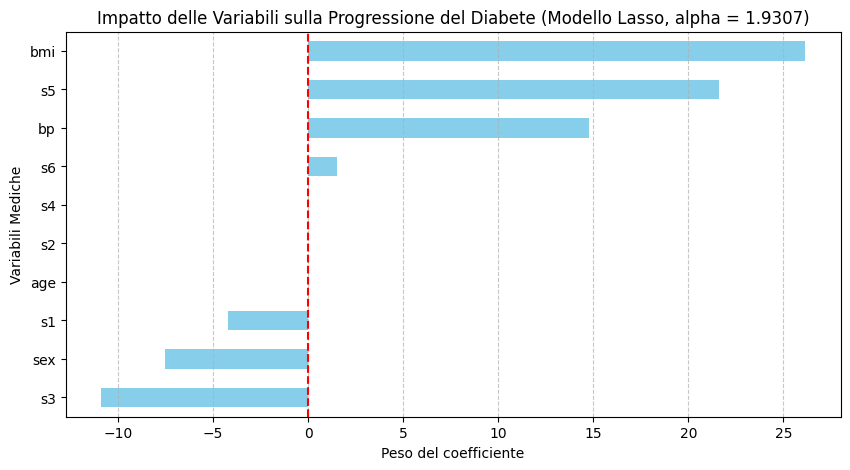

In [27]:
# Estrazione i coefficienti
coef_series = pd.Series(best_pipe.named_steps['model'].coef_, index=diabetes.feature_names)
# Identificazione variabili escluse
escluse = coef_series[coef_series == 0].index.tolist()
print(f"Variabili escluse dal modello: {escluse}")
# Grafico per visualizzare tutti i coefficienti
plt.figure(figsize=(10, 5))
coef_series.sort_values().plot(kind='barh', color='skyblue')
best_alpha = lasso_grid.best_params_['model__alpha']
plt.title(f"Impatto delle Variabili sulla Progressione del Diabete (Modello Lasso, alpha = {best_alpha:.4f})")
plt.xlabel("Peso del coefficiente")
plt.ylabel("Variabili Mediche")
plt.axvline(x=0, color='red', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [28]:
print(coef_series)

age     0.000000
sex    -7.537984
bmi    26.150560
bp     14.797112
s1     -4.214568
s2     -0.000000
s3    -10.911430
s4      0.000000
s5     21.596436
s6      1.521781
dtype: float64


I coefficienti azzerati sono age, s2 (LDL) ed s4 (colesterolo totale/HDL). Il modello ha deciso che conoscendo le altre variabili queste 3 sono irrilevanti per prevedere l'evoluzione della malattia.
Questo suggerisce che per monitorare la progressione del diabete a un anno, i medici possono concentrarsi su un set più snello di indicatori, ottimizzando risorse e tempi di analisi.
Il modello è preciso quanto la regressione Ridge, usando meno informazioni.

### Analisi dei residui

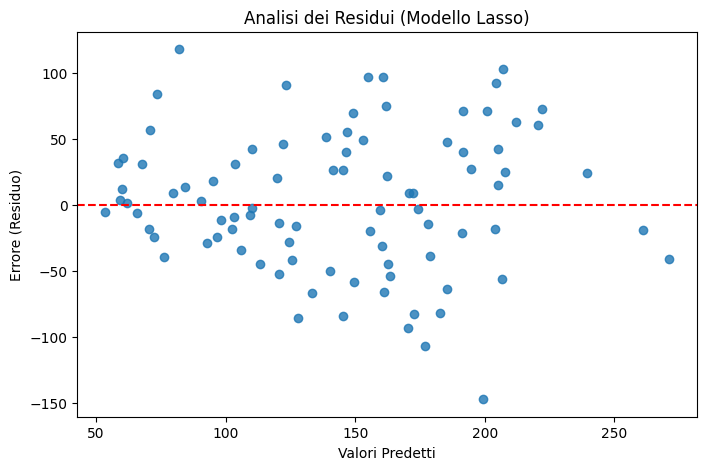

In [31]:
# Analisi dei residui
residui = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residui, alpha=0.8)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Analisi dei Residui (Modello Lasso)")
plt.xlabel("Valori Predetti")
plt.ylabel("Errore (Residuo)")
plt.show()

I punti sono sparsi, non seguono un andamento. Questo è un buon segno, significa che il modello non ha trascurato informazioni importanti

## Confronto Ridge VS Lasso

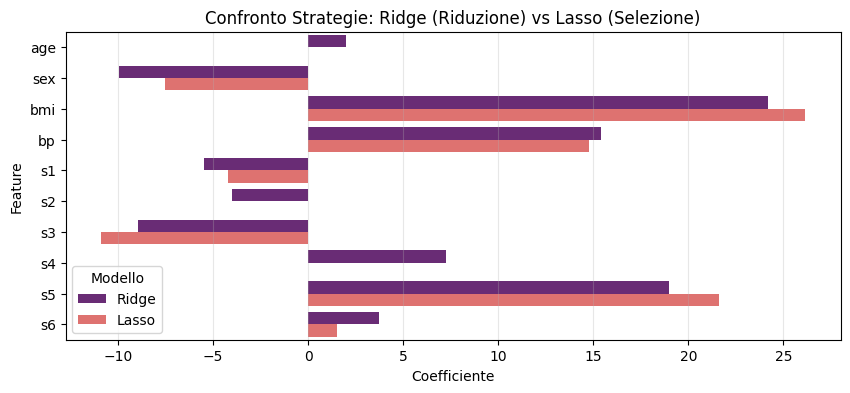

In [34]:
# Recupero coefficienti di Ridge e Lasso dai migliori stimatori trovati dalla CV
ridge_grid = next(r['Grid'] for r in results if r['Modello'] == 'Ridge') # come fatto nella cella 71 per Lasso

ridge_final = ridge_grid.best_estimator_.named_steps['model']
lasso_final = lasso_grid.best_estimator_.named_steps['model']

df_compare = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Ridge': ridge_final.coef_,
    'Lasso': lasso_final.coef_
}).melt(id_vars='Feature', var_name='Modello', value_name='Coefficiente')

plt.figure(figsize=(10, 4))
sns.barplot(data=df_compare, x='Coefficiente', y='Feature', hue='Modello', palette='magma')
plt.title("Confronto Strategie: Ridge (Riduzione) vs Lasso (Selezione)")
plt.grid(axis='x', alpha=0.3)
plt.show()

Di seguito alcune osservazioni sulle barre mostrate nel grafico.
- **BMI, s5 e bp**. Si nota che sia la Ridge che la Lasso concordano quasi perfettamente sulla loro importanza. Le barre sono lunghe e positive.
  
- **s2**. Si nota che la regressione Ridge assegna a questa variabile un piccolo peso negativo, mentre la Lasso ignora questo parametro.
  
- **sex, s1 e s3**. Entrambi i modelli le riconoscono come fattori importanti, ma con segno negativo. In questo dataset, valori più alti di queste variabili sono associati a una minore progressione della malattia. Si nota come il Lasso sia più aggressivo della Ridge nel ridurre il peso di s1, un'altra dimostrazione della sua natura selettiva.

In sintesi entrambi i modelli identificano BMI, s5 e bp come i predittori positivi più forti, confermando la loro rilevanza clinica. La differenza cruciale risiede nella gestione delle variabili meno informative: mentre la Ridge mantiene tutti i coefficienti, la Lasso azzera completamente la variabile s2 e riduce drasticamente l'impatto di s4, dimostrando la sua capacità di effettuare una selezione automatica delle feature per un modello più semplice e interpretabile.

In [37]:
# Creazione di un paziente medio usando un DataFrame con i nomi delle colonne corretti
paziente_medio = pd.DataFrame(np.zeros((1, 10)), columns=diabetes.feature_names)

# La predizione 
predizione_base = best_pipe.predict(paziente_medio)[0]

print(f"Valore base di progressione per un paziente medio: {predizione_base:.2f}")

Valore base di progressione per un paziente medio: 151.56


## Conclusioni 
Al termine di questo studio predittivo, basato su un dataset di 442 pazienti e 10 variabili cliniche, si possono trarre le seguenti conclusioni:

- **Efficacia del Modello**. Il modello Lasso (regolarizzazione L1) con α ≈ 1.9307 è risultato il più performante, raggiungendo un R2 di  0.4717 sul test set. Questo indica che quasi la metà della variabilità della malattia a un anno si può attribuire ai soli parametri clinici misurati all'inizio.

- **Identificazione dei Fattori Critici**. L'analisi dei coefficienti ha confermato in modo univoco che l'Indice di Massa Corporea (BMI) e i trigliceridi (s5) sono i predittori più influenti. Un intervento mirato su questi due fattori potrebbe avere un grande impatto nel rallentare la progressione della patologia.

- **Ottimizzazione delle Risorse**. Grazie alla proprietà di Feature Selection del Lasso, è stato dimostrato che le variabili s2 (LDL), s4 (Colesterolo totale/ HDL), age sono ridondanti ai fini della predizione. In un contesto di screening su larga scala, l'organizzazione potrebbe potenzialmente ridurre il numero di esami necessari senza perdere precisione diagnostica.

- **Limiti e Sviluppi Futuri**. L'errore residuo (RMSE ≈ 53) suggerisce che il quadro clinico è influenzato da variabili non presenti nel dataset (es. attività fisica, dieta, genetica). Per superare la soglia del 50% di accuratezza, sarebbe necessario integrare dati comportamentali dei pazienti.
